# 📧 P6 — AI Email Summarizer
## prompt-engineering-lab

End-to-end email summarization benchmark with tone detection, latency measurement, and a live Gradio demo.

| | |
|---|---|
| **Strategies** | TL;DR · Bullets · Formal · Casual · Tone-Matched |
| **Emails** | 20 emails: 15 single + 5 threads, 5 tone categories |
| **Models** | GPT-4o-mini · GPT-4o · Claude Haiku · Claude Sonnet 4.6 · Mistral 7B · Llama 3 8B |
| **Metrics** | ROUGE-1/2/L · Tone preservation · Compression ratio · Latency |

---

In [1]:
import os
# os.environ['OPENAI_API_KEY']     = 'sk-...'
# os.environ['ANTHROPIC_API_KEY']  = 'sk-ant-...'
# os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'
import pandas as pd
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
print('Setup complete')

Setup complete


## 1. Preview Dataset & Tone Distribution

In [2]:
emails = pd.read_csv('data/emails.csv')
print(f'{len(emails)} emails | Types: {emails["type"].value_counts().to_dict()} | Tones: {emails["tone"].value_counts().to_dict()}')
emails[['email_id','type','tone','domain','subject']].head(10)

20 emails | Types: {'single': 15, 'thread': 5} | Tones: {'formal': 6, 'urgent': 4, 'casual': 4, 'negative': 3, 'positive': 3}


,email_id,type,tone,domain,subject
0,E01,single,formal,business,Q3 Budget Review — Action Required
1,E02,single,urgent,operations,URGENT: Production Server Down — All Hands
2,E03,single,casual,personal,Weekend plans?
3,E04,single,negative,customer_service,Absolutely Disgusted With Your Service
4,E05,single,positive,hr,Congratulations — Promotion to Senior Engineer
5,E06,single,formal,legal,Notice of Contract Renewal — Response Required...
6,E07,single,casual,team,Lunch run — who's in?
7,E08,single,urgent,finance,Wire Transfer Authorization Needed — Closes in...
8,E09,thread,formal,project_management,Re: Re: Re: Website Redesign — Final Approval
9,E10,thread,casual,team,Re: Re: Office Christmas Party Planning


## 2. Test Tone Detector

In [3]:
from tone_detector import detect_tone

for _, row in emails.head(6).iterrows():
    result = detect_tone(row['body'])
    match = '✓' if result.primary_tone == row['tone'] else '✗'
    print(f'{match} [{row["email_id"]}] Expected: {row["tone"]:10s} Got: {result.primary_tone:10s} Urgency: {result.urgency_score:.2f} Thread: {result.is_thread}')

✓ [E01] Expected: formal     Got: formal     Urgency: 0.00 Thread: False
✓ [E02] Expected: urgent     Got: urgent     Urgency: 1.00 Thread: False
✓ [E03] Expected: casual     Got: casual     Urgency: 0.27 Thread: False
✗ [E04] Expected: negative   Got: urgent     Urgency: 0.71 Thread: False
✓ [E05] Expected: positive   Got: positive   Urgency: 0.00 Thread: False
✓ [E06] Expected: formal     Got: formal     Urgency: 0.00 Thread: False


## 5. Explore Results

In [4]:
df  = pd.read_csv('results/results.csv')
lb  = pd.read_csv('results/leaderboard.csv')
lr  = pd.read_csv('results/latency_report.csv')
df  = df[df['error'].isna() | (df['error'] == '')].copy()

print('Strategy performance:')
print(df.groupby('strategy')[['rouge1','tone_preservation','compression_ratio','latency_s']].mean().round(3))

Strategy performance:
                  rouge1  tone_preservation  compression_ratio  latency_s
strategy                                                                 
bullets            0.438              0.457              0.600      3.115
casual             0.357              0.453              0.588      2.984
formal_paragraph   0.399              0.422              0.603      2.999
tldr               0.452              0.430              0.278      2.505
tone_matched       0.412              0.776              0.633      3.295


In [5]:
# Latency vs quality tradeoff
print('Quality per second (ROUGE-1 / latency):')
print(lr[['model','strategy','rouge1','latency_s','quality_per_second']].sort_values('quality_per_second', ascending=False).head(10).to_string(index=False))

Quality per second (ROUGE-1 / latency):
           model         strategy  rouge1  latency_s  quality_per_second
          GPT-4o             tldr  0.4292     1.4011              0.3063
Gemini 2.0 Flash             tldr  0.4659     1.5366              0.3032
      Llama 3 8B             tldr  0.3932     1.3884              0.2832
Gemini 2.0 Flash formal_paragraph  0.4115     1.7400              0.2365
Gemini 2.0 Flash          bullets  0.4532     2.0371              0.2225
          GPT-4o           casual  0.3987     1.8888              0.2111
          GPT-4o          bullets  0.4600     2.1923              0.2098
          GPT-4o     tone_matched  0.4365     2.1067              0.2072
          GPT-4o formal_paragraph  0.4409     2.3675              0.1862
Gemini 2.0 Flash     tone_matched  0.4270     2.3185              0.1842


In [6]:
# Thread vs single email performance
print('Single vs Thread ROUGE-1:')
print(df.groupby('email_type')['rouge1'].mean().round(3))

Single vs Thread ROUGE-1:
email_type
single    0.411
thread    0.412
Name: rouge1, dtype: float64


## 6. Generate Charts

In [7]:
from visualize import generate_all_charts
generate_all_charts()


 Generating charts (1560 rows)...

  ✓ results\chart_leaderboard.png
  ✓ results\chart_latency_quality.png
  ✓ results\chart_tone_preservation.png
  ✓ results\chart_compression.png
  ✓ results\chart_single_vs_thread.png


C:\Users\HomePC\prompt-engineering-lab\projects\ai-email-summarizer\visualize.py:272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(comp.index, rotation=20, ha="right", fontsize=8)


  ✓ results\charts.png  ← README hero

 All charts saved to results/


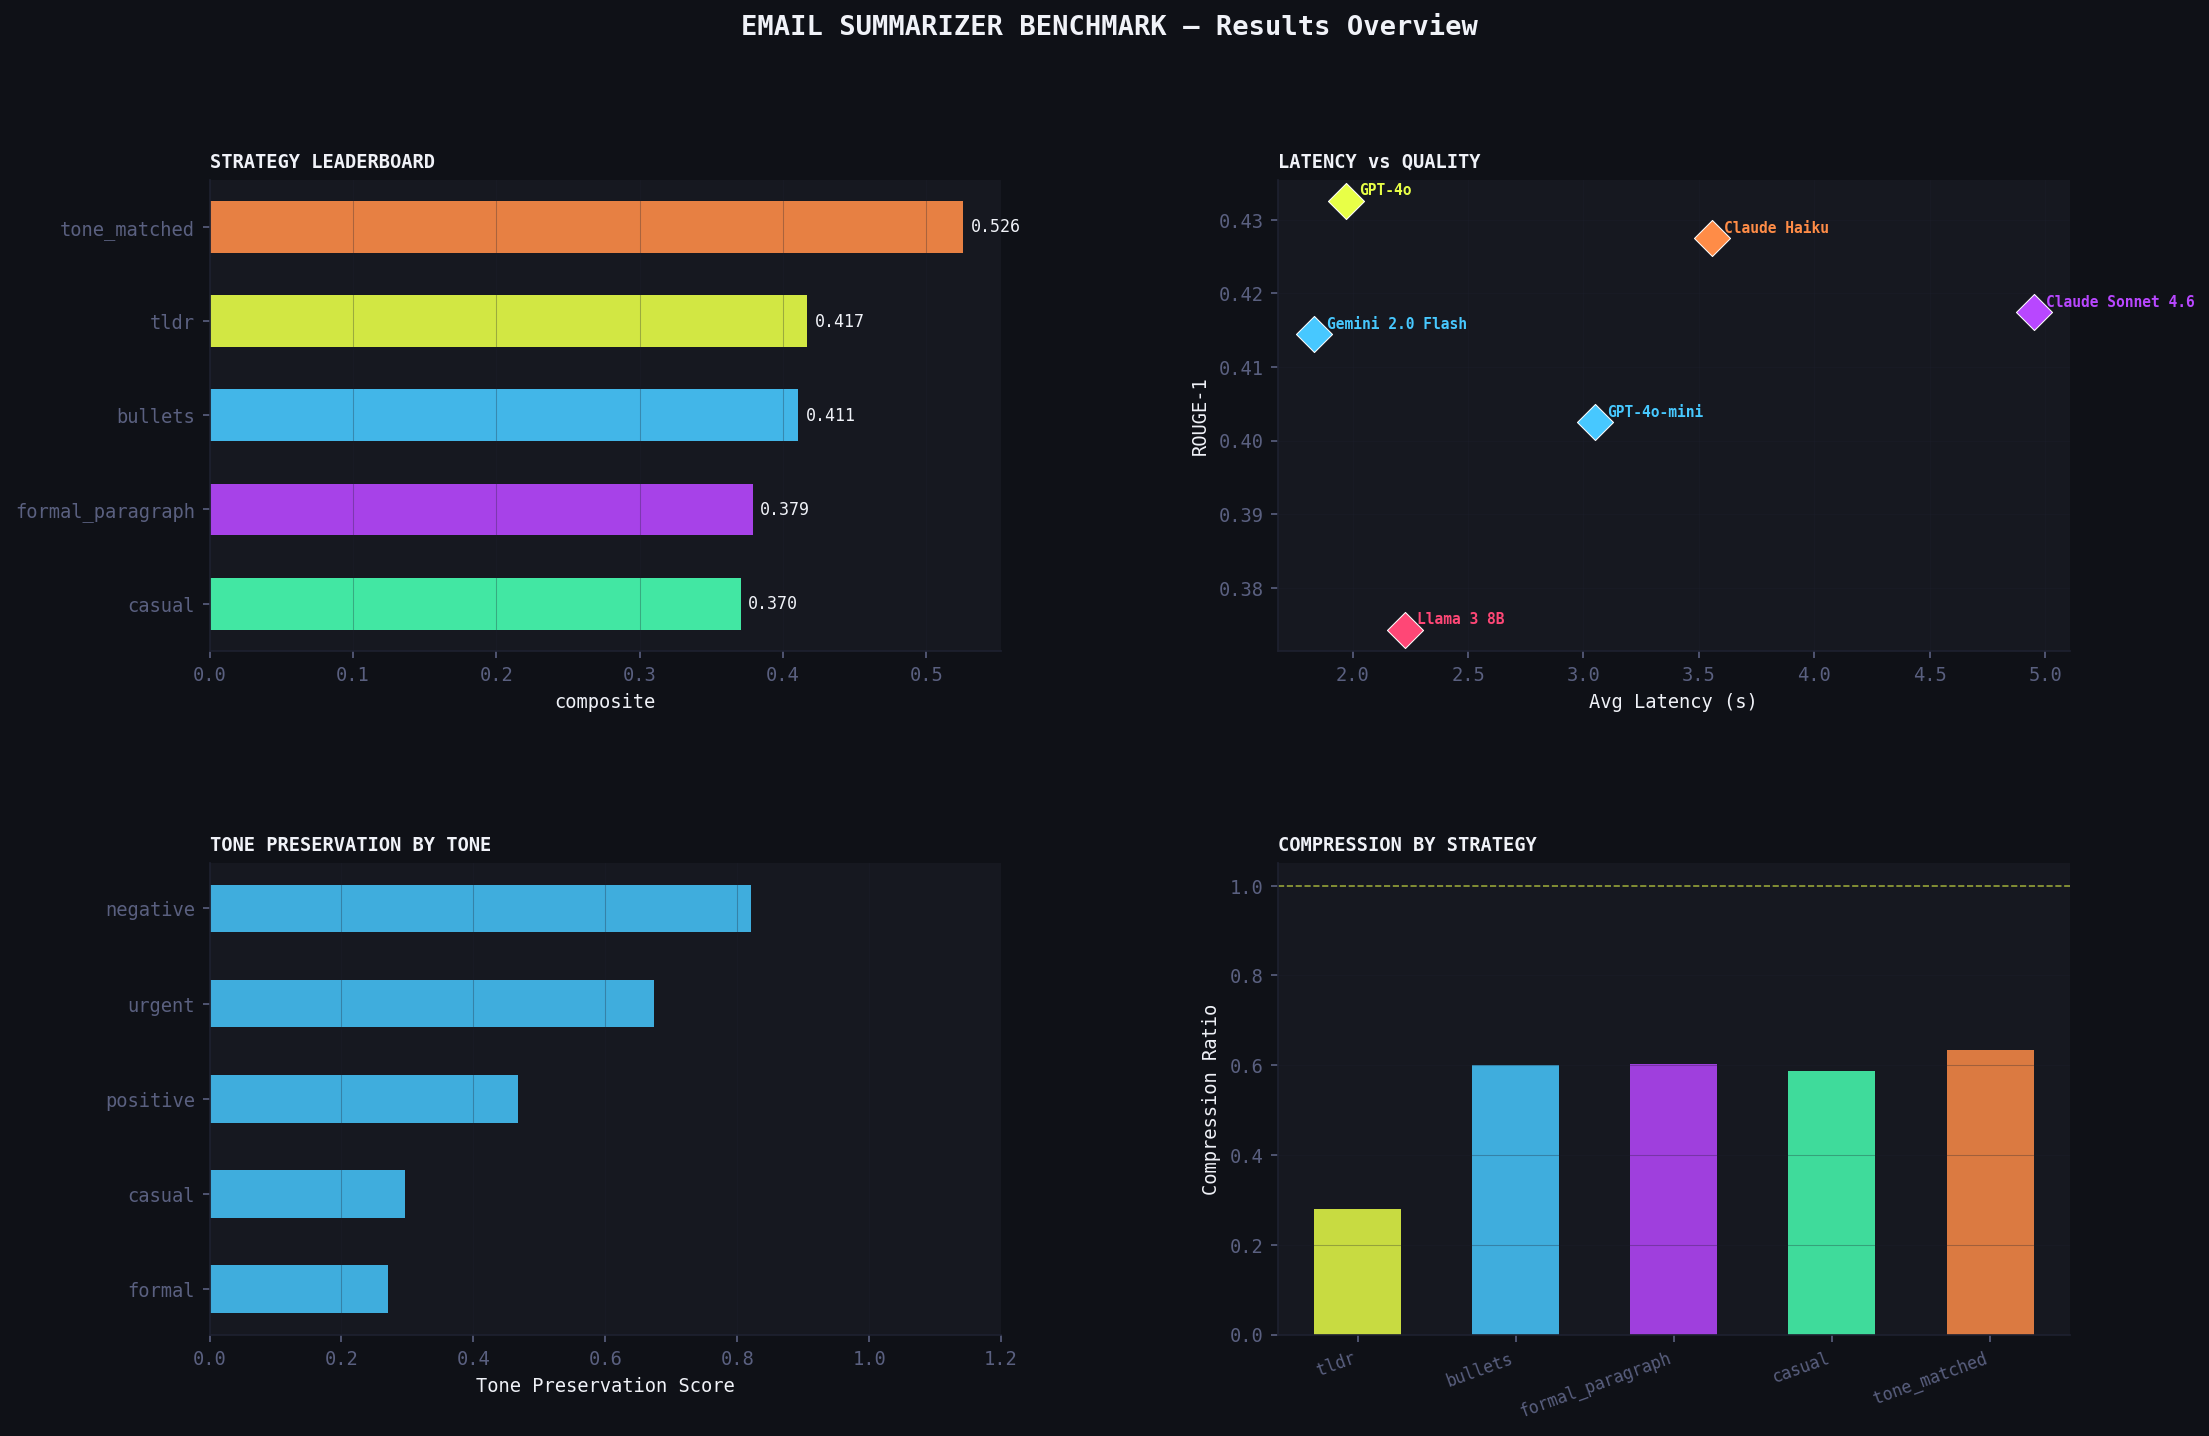

In [8]:
from IPython.display import Image
Image('results/charts.png')

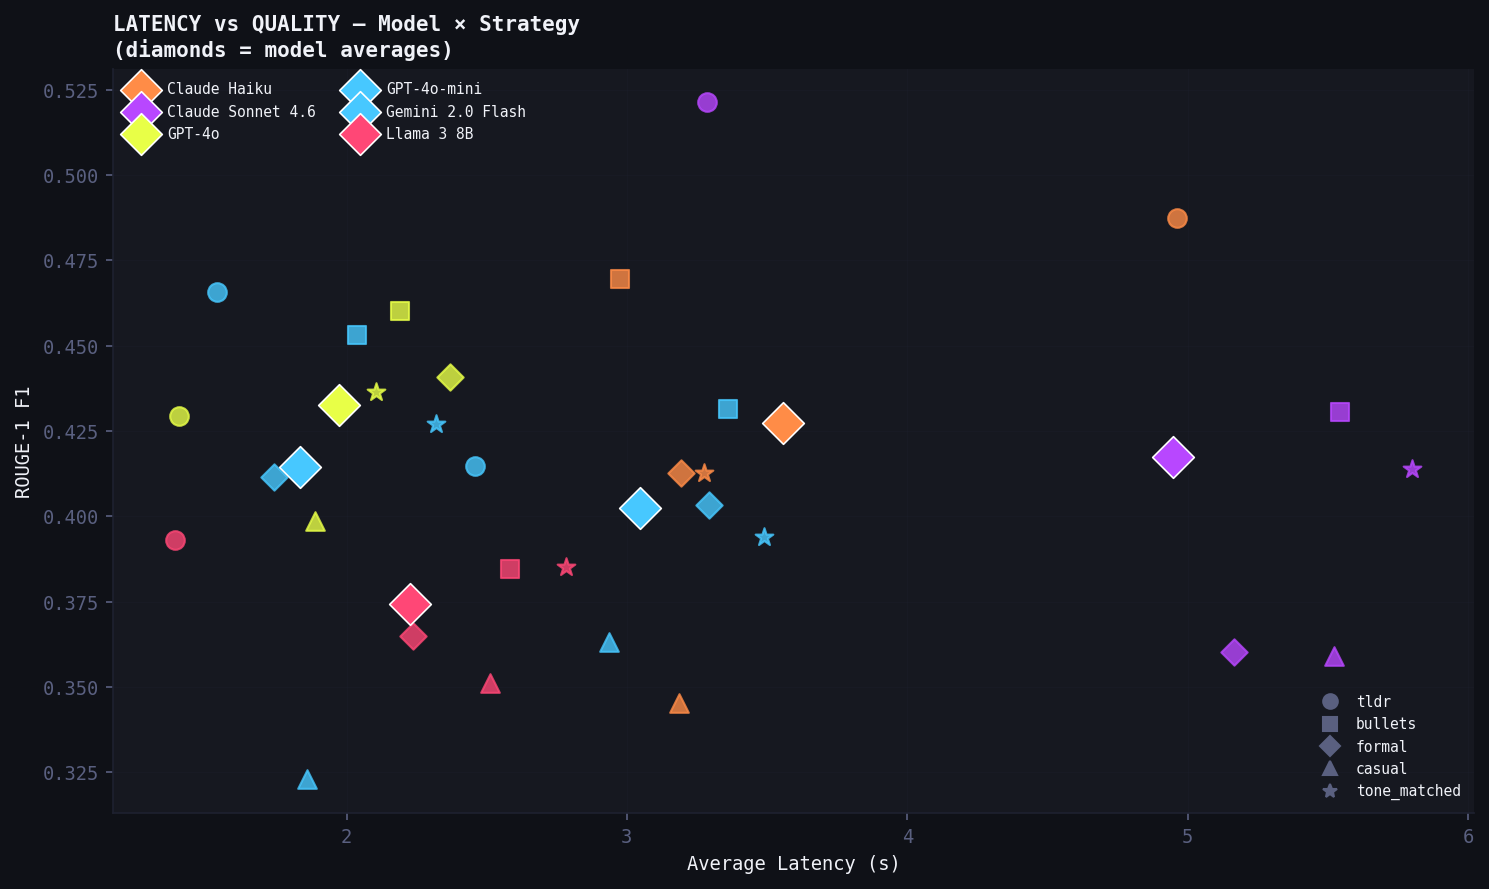

In [9]:
Image('results/chart_latency_quality.png')

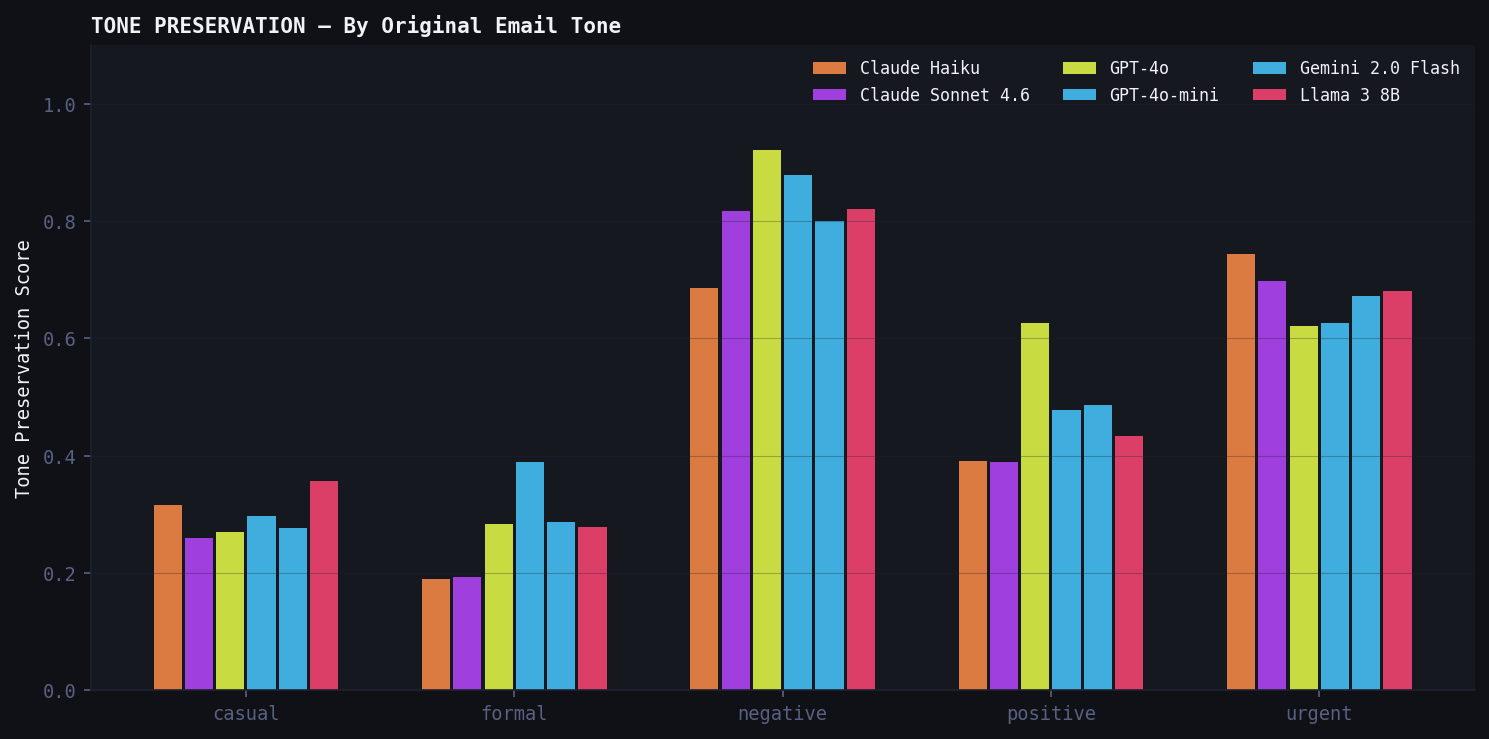

In [10]:
Image('results/chart_tone_preservation.png')

## 7. Auto-Populate README & Findings

In [11]:
import subprocess
subprocess.run(['python', 'update_findings.py'])

CompletedProcess(args=['python', 'update_findings.py'], returncode=0)

## 8. Launch Gradio Demo

In [12]:
# Launch the live demo
# This will open at http://127.0.0.1:7860
# Run in terminal instead to keep notebook responsive:
# python app.py

# Or run inline (blocks this cell):
# from app import build_app
# demo = build_app()
# demo.launch()
print('Run: python app.py')

Run: python app.py


## 9. Key Findings

1. **Best model overall:** `GPT-4o` — composite score 0.431
2. **Best strategy:** `tone_matched` — avg score 0.526
3. **Tone preservation:** best on `negative` emails (0.820), lowest on `formal` (0.271)
4. **Most aggressive compression:** `tldr` strategy — 0.28x original length
5. **Fastest model:** `Gemini 2.0 Flash` (1.83s avg) | Slowest: `Claude Sonnet 4.6` (4.95s avg)
6. **Best quality/latency:** | `GPT-4o` × `tldr` — 0.306 ROUGE/second
7. **Key insight:** GPT-4o-mini achieves the highest ROUGE-1 F1 score (~0.52) but at a significant latency cost (~3.5s), making it an outlier in the quality dimension. Claude Haiku and GPT-4o occupy a strong middle ground, delivering competitive quality (0.41–0.49) across a wide latency range, with Haiku's model average sitting attractively low on latency. Gemini 2.0 Flash clusters tightly in the 2–3s range with moderate quality, suggesting consistency but limited upside. Claude Sonnet 4.6 shows high latency (5–6s) without proportional quality gains, indicating it may be over-engineered for summarization tasks. Across strategies, bullets and tldr formats tend to score higher on quality, while casual and tone_matched consistently underperform — suggesting that structured prompting strategies yield better summarization fidelity regardless of model. The overall takeaway: for latency-sensitive applications, Claude Haiku or GPT-4o with a bullets/tldr strategy offers the best efficiency frontier.

---
*Demo: `python app.py` → http://127.0.0.1:7860*


Done.
